In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random

In [3]:
#Load Dataset

df_companies = pd.read_csv('/kaggle/input/datasets/giandocannone/input-dataset/data.csv')
df_companies

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


Number of solvent companies: 6599
Number of insolvent companies: 220


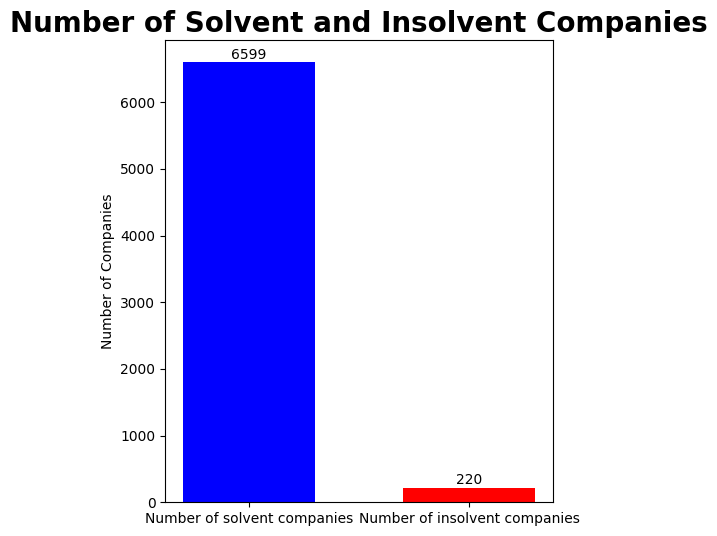

In [4]:
# Count the number of solvent and insolvent companies in the column
anzahl_pro_wert = df_companies['Bankrupt?'].value_counts()

# Ausgabe der Zählungen
anzahl_der_nuller = anzahl_pro_wert.get(0, 0)  # Falls es keine 0 gibt, wird 0 zurückgegeben
anzahl_der_einer = anzahl_pro_wert.get(1, 0)  # Falls es keine 1 gibt, wird 0 zurückgegeben

# Print the number of solvent companies
print(f"Number of solvent companies: {anzahl_der_nuller}")

# Print the number of insolvent companies
print(f"Number of insolvent companies: {anzahl_der_einer}")

# Define a list to store the numbers
anzahl_var = [anzahl_der_nuller, anzahl_der_einer]

# Define labels for the bar chart
anzahl_var_labels = ['Number of solvent companies', 'Number of insolvent companies']

# Create a new figure for the plot
plt.figure(figsize=(5,6))

# Set up the x-positions for the bars
x_pos = np.arange(len(anzahl_var))

# Create the bar chart
bar_width = 0.6
bars = plt.bar(x_pos, anzahl_var, width=bar_width, color=['blue', 'red'], 
               tick_label=anzahl_var_labels)

# Add labels and a legend to the plot
plt.ylabel('Number of Companies')
plt.title('Number of Solvent and Insolvent Companies', fontsize=20, fontweight='bold')

# Add text labels to each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 5, str(yval), ha='center', va='bottom')

# Display the plot
plt.show()

In [5]:
good_companies = df_companies[df_companies['Bankrupt?'] == 0]
insolvent_companies = df_companies[df_companies['Bankrupt?'] == 1]

   TAGR  TAGR avg solv  TAGR avg insolv
0     1   5.531603e+09     4.803017e+09


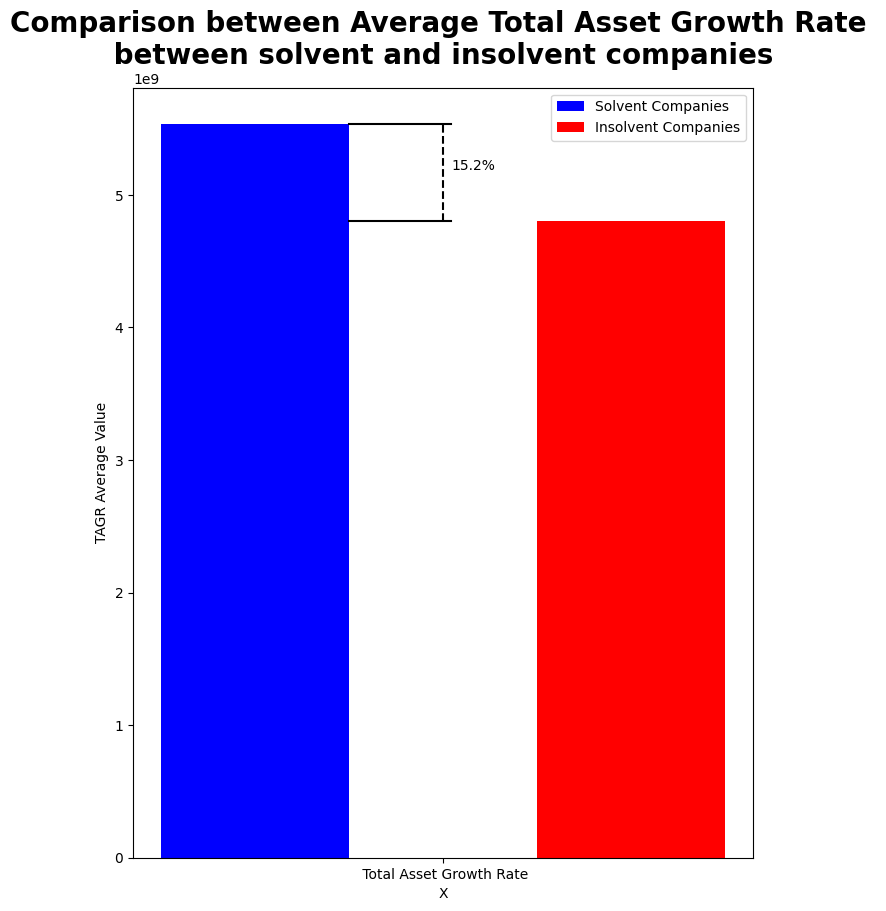

In [6]:
# Time Series Development: How do critical key metrics evolve before bankruptcy?

# We need to find one or more key metrics that correlate with the outcome after taxes and interest / total assets (X3)
# Ask Chatbot for help
# Found: Total Asset Growth Rate

# No sampling is needed here, we want to highlight that larger companies with stronger financials are influencing these values
TAGR_val_dict = {
    'TAGR': [1],
    'TAGR avg solv': [good_companies[' Total Asset Growth Rate'].mean()],
    'TAGR avg insolv': [insolvent_companies[' Total Asset Growth Rate'].mean()]
}

df_TAGR_val = pd.DataFrame(TAGR_val_dict)
print(df_TAGR_val)

TAGR_var = df_TAGR_val['TAGR']
TAGR_var_labels = [' Total Asset Growth Rate']
TAGR_avg_solv = df_TAGR_val['TAGR avg solv']
TAGR_avg_insolv = df_TAGR_val['TAGR avg insolv']

# Initialize figure
plt.figure(figsize=(8,10))

# Create bar chart
bar_width = 0.25
plt.bar(TAGR_var - bar_width, TAGR_avg_solv, width=bar_width, color='blue', label='Solvent Companies')
plt.bar(TAGR_var + bar_width, TAGR_avg_insolv, width=bar_width, color='red',label='Insolvent Companies')

# Add labels, legend, and ticks
plt.xlabel('X')
plt.title('Comparison between Average Total Asset Growth Rate \n between solvent and insolvent companies ', fontsize=20, fontweight='bold')
plt.ylabel('TAGR Average Value')
plt.legend()
plt.xticks(TAGR_var, TAGR_var_labels)

# Calculate and display delta in percentage
for i in range(len(TAGR_var)):
    solvent_value = TAGR_avg_solv[i]
    insolvent_value = TAGR_avg_insolv[i]
    delta = ((solvent_value - insolvent_value) / insolvent_value) * 100
    plt.text(TAGR_var[i]+0.04, (max(solvent_value, insolvent_value) + min(solvent_value, insolvent_value))/2,
             f'{delta:.1f}%', ha='center', va='bottom')
    plt.plot([TAGR_var[i], TAGR_var[i]], [insolvent_value, solvent_value],color='black', lw=1.5, linestyle='--')
    plt.plot([TAGR_var[i]-bar_width/2, TAGR_var[i]+0.01], [insolvent_value, insolvent_value],color='black', lw=1.5)
    plt.plot([TAGR_var[i]-bar_width/2, TAGR_var[i]+0.01], [solvent_value, solvent_value],color='black', lw=1.5)

# Display plot
plt.show()

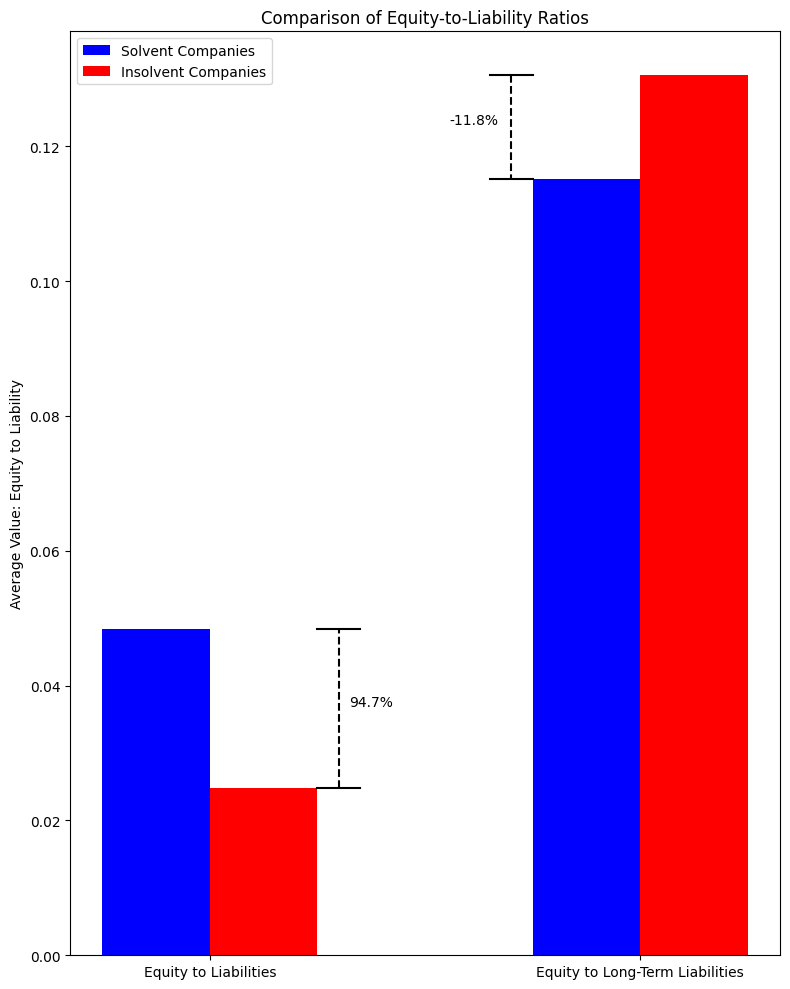

In [7]:
# X4: Market Value of Equity / Total Debt
# This ratio measures how much a company's assets can decline in value before 
# its liabilities exceed its assets, leading to insolvency/bankruptcy.
# The dataset contains two metrics representing short-term (current) and long-term liabilities.
# We calculate the mean for both solvent and insolvent companies to analyze these financial indicators:

X_val_dict = {
    'X': [1, 2],
    'X avg solv': [good_companies[' Equity to Liability'].mean(), good_companies[' Equity to Long-term Liability'].mean()],
    'X avg insolv': [insolvent_companies[' Equity to Liability'].mean(), insolvent_companies[' Equity to Long-term Liability'].mean()]
}

df_X_val = pd.DataFrame(X_val_dict)

X_var = df_X_val['X']
X_var_labels = ['Equity to Liabilities', 'Equity to Long-Term Liabilities']
X_avg_solv = df_X_val['X avg solv']
X_avg_insolv = df_X_val['X avg insolv']

# --- SET BAR LAYOUT (COUNT, WIDTH) ---

# INITIALIZE FIGURE
plt.figure(figsize=(8, 10))

# CREATE BAR CHART
bar_width = 0.25
plt.bar(X_var - bar_width/2, X_avg_solv, width=bar_width, color='blue', label='Solvent Companies')
plt.bar(X_var + bar_width/2, X_avg_insolv, width=bar_width, color='red', label='Insolvent Companies')

# --- ADD LABELS, LEGEND, AND TICKS ---
plt.title('Comparison of Equity-to-Liability Ratios')
plt.ylabel('Average Value: Equity to Liability')
plt.legend()
plt.xticks(X_var, X_var_labels)

# Calculate and place the percentage delta (difference)
for i in range(len(X_var)):
    solvent_value = X_avg_solv[i]
    insolvent_value = X_avg_insolv[i]
    
    # Calculate percentage difference
    delta = ((solvent_value - insolvent_value) / insolvent_value) * 100
    
    # Logic for positioning the delta annotations
    if i % 2 == 0:
        plt.text(X_var[i] + 3*bar_width/2, 
                 (max(solvent_value, insolvent_value) + min(solvent_value, insolvent_value)) / 2, 
                 f'{delta:.1f}%', ha='center', va='bottom')
        plt.plot([X_var[i]+bar_width, X_var[i]+bar_width+0.1], [insolvent_value, insolvent_value], color='black', lw=1.5)
        plt.plot([X_var[i]+bar_width, X_var[i]+bar_width+0.1], [solvent_value, solvent_value], color='black', lw=1.5)
        plt.plot([X_var[i]+1.2*bar_width, X_var[i]+1.2*bar_width], [insolvent_value, solvent_value], color='black', lw=1.5, linestyle='--')
    else:
        plt.text(X_var[i] - 3.1*bar_width/2, 
                 (max(solvent_value, insolvent_value) + min(solvent_value, insolvent_value)) / 2, 
                 f'{delta:.1f}%', ha='center', va='bottom')
        plt.plot([X_var[i]-bar_width, X_var[i]-1.8*bar_width+0.1], [insolvent_value, insolvent_value], color='black', lw=1.5)
        plt.plot([X_var[i]-bar_width, X_var[i]-1.8*bar_width+0.1], [solvent_value, solvent_value], color='black', lw=1.5)
        plt.plot([X_var[i]-1.2*bar_width, X_var[i]-1.2*bar_width], [insolvent_value, solvent_value], color='black', lw=1.5, linestyle='--')

plt.tight_layout() # Added for better spacing
plt.show()

In [8]:
# According to Altman, the financial ratios that best predict a company's bankruptcy risk are:

# X1: Working Capital / Total Assets
# A measure of the company's net liquidity relative to its total capitalization.
# X1 = (Working Capital) / (Total Assets)

# X2: Retained Earnings / Total Assets
# A measure of cumulative profitability over time, which also reflects the age of the firm.
# X2 = (Retained Earnings) / (Total Assets)

# X3: Earnings Before Interest and Taxes / Total Assets
# A measure of the true productivity of a firm's total assets, independent of tax and leverage factors.
# Since this metric is not directly available in the dataset, X3 is recalculated as:
# X3 = (ROA(A) before interest and % after tax) / (1 - Tax Rate(A))

# X4: Market Value of Equity / Total Debt
# This measure indicates how much a firm's assets can decline in value before liabilities 
# exceed assets, leading to insolvency.
# The dataset contains two metrics for short-term and long-term liabilities. 
# We will use the average of the two: 
# X4 = 0.5 * (Equity / Liability) + 0.5 * (Equity / Long-term Liability)

# X5: Sales / Total Assets
# A measure of the firm's sales generation power and the management's ability 
# to deal with competitive market conditions.
# In the dataset, this metric is labeled as: 
# X5 = Total Asset Turnover

# --- Calculate the above ratios and the Z-Score for solvent companies ---

X0_1 = good_companies[' Working Capital to Total Assets']
X0_2 = good_companies[' Retained Earnings to Total Assets']
X0_3 = good_companies[' ROA(A) before interest and % after tax'] / (1 - good_companies[' Tax rate (A)'])
X0_4 = good_companies[' Equity to Liability']
X0_5 = good_companies[' Total Asset Turnover']

TAGR_0 = good_companies[' Total Asset Growth Rate'] 

# Applying the Altman Z-Score formula for solvent companies
Z0 = [1.2*X0_1.iloc[i] + 1.4*X0_2.iloc[i] + 3.3*X0_3.iloc[i] + 0.6*X0_4.iloc[i] + 1.0*X0_5.iloc[i] for i in range(len(X0_1))]

# --- Calculate the above ratios and the Z-Score for insolvent companies ---

X1_1 = insolvent_companies[' Working Capital to Total Assets']
X1_2 = insolvent_companies[' Retained Earnings to Total Assets']
X1_3 = insolvent_companies[' ROA(A) before interest and % after tax'] / (1 - insolvent_companies[' Tax rate (A)'])
X1_4 = insolvent_companies[' Equity to Liability']
X1_5 = insolvent_companies[' Total Asset Turnover']

TAGR_1 = insolvent_companies[' Total Asset Growth Rate'] 

# Applying the Altman Z-Score formula for insolvent companies
Z1 = [1.2*X1_1.iloc[i] + 1.4*X1_2.iloc[i] + 3.3*X1_3.iloc[i] + 0.6*X1_4.iloc[i] + 1.0*X1_5.iloc[i] for i in range(len(X1_1))]

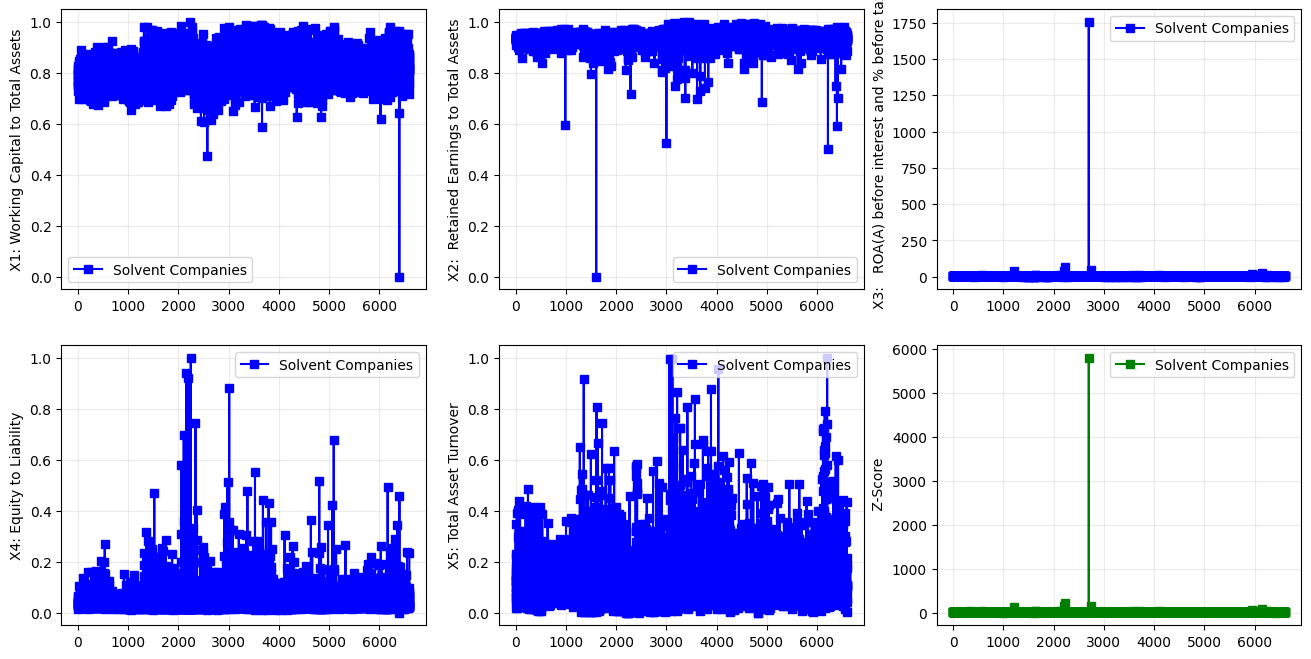

In [9]:
companies_index = np.linspace(0, len(good_companies)-1,len(good_companies))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Use the axes for plotting
axes[0,0].plot(companies_index, X0_1, 's-b')
axes[0,0].grid('--', alpha = 0.25)
axes[0,0].set_ylabel('X1: Working Capital to Total Assets')
axes[0,0].legend(['Solvent Companies'])


# Use the axes for plotting
axes[0,1].plot(companies_index, X0_2, 's-b')
axes[0,1].grid('--', alpha = 0.25)
axes[0,1].set_ylabel('X2:  Retained Earnings to Total Assets')
axes[0,1].legend(['Solvent Companies'])

# Use the axes for plotting
axes[0,2].plot(companies_index, X0_3, 's-b')
axes[0,2].grid('--', alpha = 0.25)
axes[0,2].set_ylabel('X3:   ROA(A) before interest and % before tax')
axes[0,2].legend(['Solvent Companies']);

# Use the axes for plotting

axes[1,0].plot(companies_index, X0_4, 's-b')
axes[1,0].grid('--', alpha = 0.25)
axes[1,0].set_ylabel('X4: Equity to Liability')
axes[1,0].legend(['Solvent Companies']);

# Use the axes for plotting

axes[1,1].plot(companies_index, X0_5, 's-b')
axes[1,1].grid('--', alpha = 0.25)
axes[1,1].set_ylabel('X5: Total Asset Turnover')
axes[1,1].legend(['Solvent Companies']);

# Use the axes for plotting

axes[1,2].plot(companies_index, Z0, 's-g')
axes[1,2].grid('--', alpha = 0.25)
axes[1,2].set_ylabel(' Z-Score')
axes[1,2].legend(['Solvent Companies']);



In [10]:
# Initial data cleaning: removing the first set of outliers 

# Method to find indices of infinite (inf) values
inf_indices = np.where(np.isinf(X0_3))[0]
X0_3.replace([np.inf, -np.inf], np.nan, inplace=True)
# print(inf_indices)

# Drop infinite values from all features
X0_1 = X0_1.drop(index=inf_indices)
X0_2 = X0_2.drop(index=inf_indices)
X0_3 = X0_3.drop(index=inf_indices)
X0_4 = X0_4.drop(index=inf_indices)
X0_5 = X0_5.drop(index=inf_indices)

# Identify indices of outliers based on specific thresholds
outlier_X0_1_index = X0_1[X0_1 < 0.5].index
outlier_X0_2_index = X0_2[X0_2 < 0.58].index
outlier_X0_3_index = X0_3[X0_3 > 1000].index
outlier_X0_4_index = X0_4[X0_4 > 0.99].index
outlier_X0_5_index = X0_5[X0_5 > 0.99].index

index_list = [outlier_X0_1_index, outlier_X0_2_index, outlier_X0_3_index, outlier_X0_4_index, outlier_X0_5_index]

# Combine all outlier indices
combined_outliers = index_list[0]
for index in index_list[1:]:
    combined_outliers = combined_outliers.union(index)

# Drop outliers from all features and the growth rate
X0_1 = X0_1.drop(index=combined_outliers)
X0_2 = X0_2.drop(index=combined_outliers)
X0_3 = X0_3.drop(index=combined_outliers)
X0_4 = X0_4.drop(index=combined_outliers)
X0_5 = X0_5.drop(index=combined_outliers)

TAGR_0 = TAGR_0.drop(index=combined_outliers)

# Recalculate Z-Score for solvent companies after cleaning
Z0 = [1.2*X0_1.iloc[i] + 1.4*X0_2.iloc[i] + 3.3*X0_3.iloc[i] + 0.6*X0_4.iloc[i] + 1.0*X0_5.iloc[i] for i in range(len(X0_1))]

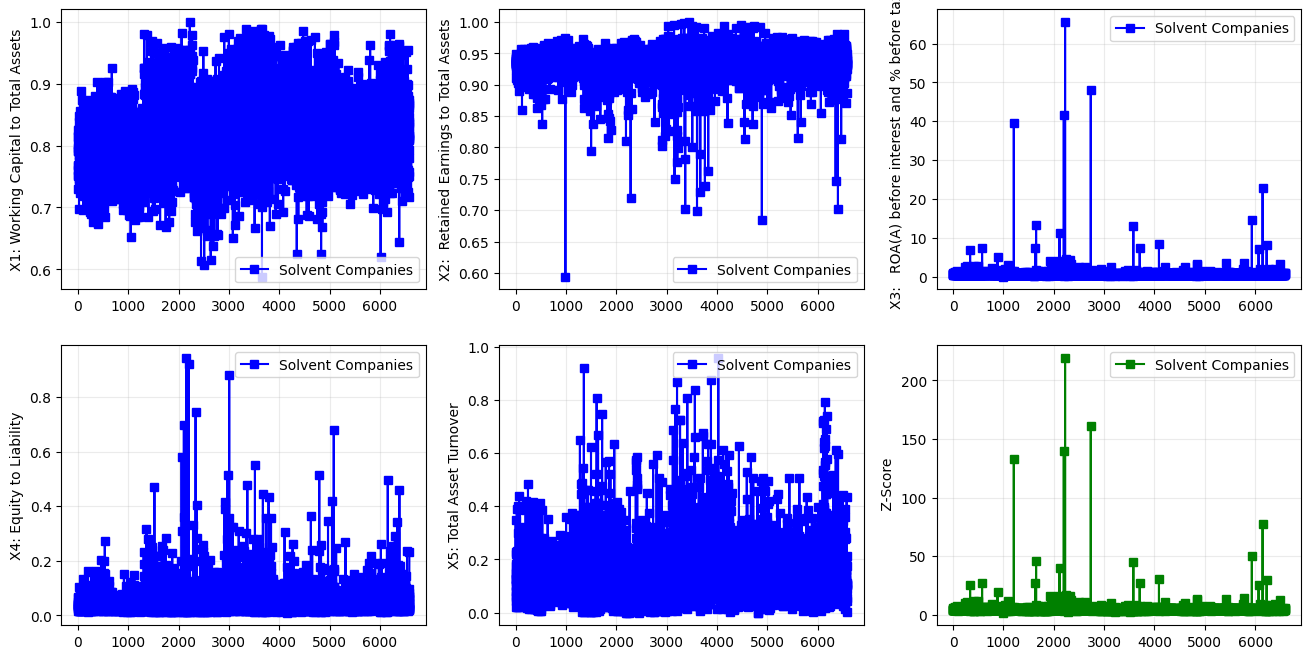

In [11]:
#Visualize Data after cleaning

companies_index = np.linspace(0, len(X0_1)-1,len(X0_1))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Use the axes for plotting
axes[0,0].plot(companies_index, X0_1, 's-b')
axes[0,0].grid('--', alpha = 0.25)
axes[0,0].set_ylabel('X1: Working Capital to Total Assets')
axes[0,0].legend(['Solvent Companies'])


# Use the axes for plotting
axes[0,1].plot(companies_index, X0_2, 's-b')
axes[0,1].grid('--', alpha = 0.25)
axes[0,1].set_ylabel('X2:  Retained Earnings to Total Assets')
axes[0,1].legend(['Solvent Companies'])

# Use the axes for plotting
axes[0,2].plot(companies_index, X0_3, 's-b')
axes[0,2].grid('--', alpha = 0.25)
axes[0,2].set_ylabel('X3:   ROA(A) before interest and % before tax')
axes[0,2].legend(['Solvent Companies']);

# Use the axes for plotting

axes[1,0].plot(companies_index, X0_4, 's-b')
axes[1,0].grid('--', alpha = 0.25)
axes[1,0].set_ylabel('X4: Equity to Liability')
axes[1,0].legend(['Solvent Companies']);

# Use the axes for plotting

axes[1,1].plot(companies_index, X0_5, 's-b')
axes[1,1].grid('--', alpha = 0.25)
axes[1,1].set_ylabel('X5: Total Asset Turnover')
axes[1,1].legend(['Solvent Companies']);

# Use the axes for plotting

axes[1,2].plot(companies_index, Z0, 's-g')
axes[1,2].grid('--', alpha = 0.25)
axes[1,2].set_ylabel(' Z-Score')
axes[1,2].legend(['Solvent Companies']);




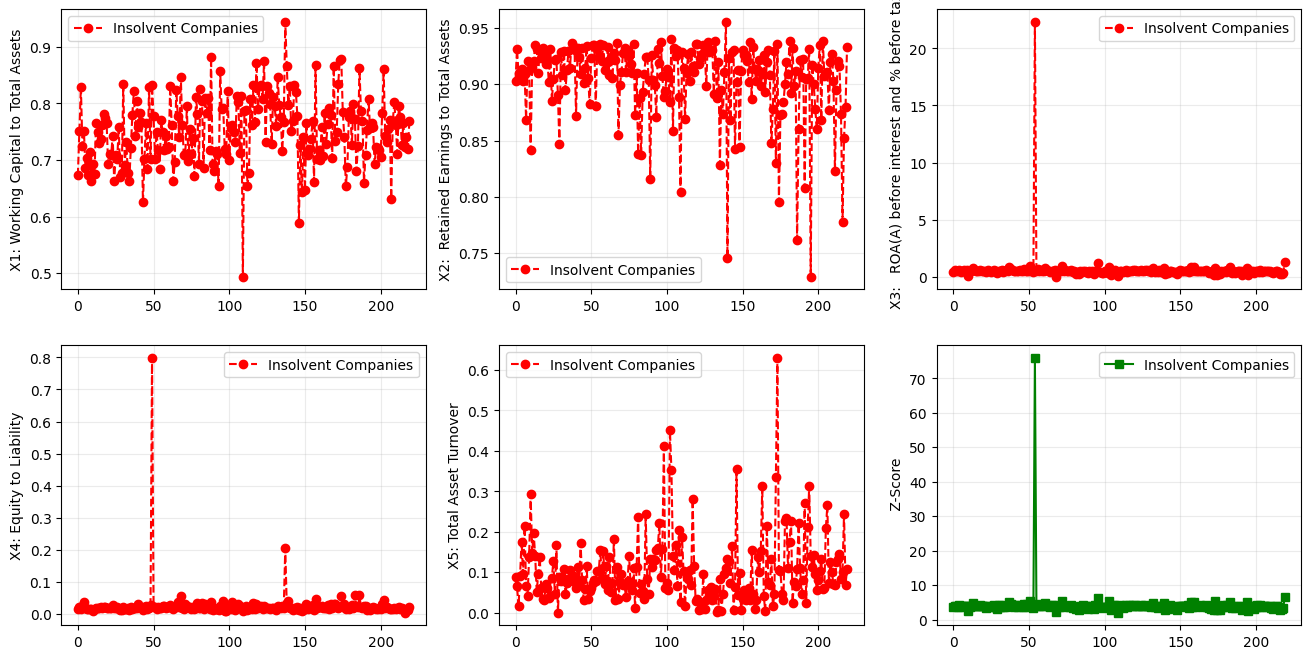

In [12]:
companies_index = np.linspace(0, len(X1_1)-1,len(X1_1))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Use the axes for plotting
axes[0,0].plot(companies_index, X1_1, 'o--r')
axes[0,0].grid('--', alpha = 0.25)
axes[0,0].set_ylabel('X1: Working Capital to Total Assets')
axes[0,0].legend(['Insolvent Companies'])


# Use the axes for plotting
axes[0,1].plot(companies_index, X1_2, 'o--r')
axes[0,1].grid('--', alpha = 0.25)
axes[0,1].set_ylabel('X2:  Retained Earnings to Total Assets')
axes[0,1].legend(['Insolvent Companies'])

# Use the axes for plotting
axes[0,2].plot(companies_index, X1_3, 'o--r')
axes[0,2].grid('--', alpha = 0.25)
axes[0,2].set_ylabel('X3:   ROA(A) before interest and % before tax')
axes[0,2].legend(['Insolvent Companies']);

# Use the axes for plotting
axes[1,0].plot(companies_index, X1_4, 'o--r')
axes[1,0].grid('--', alpha = 0.25)
axes[1,0].set_ylabel('X4: Equity to Liability')
axes[1,0].legend(['Insolvent Companies']);

# Use the axes for plotting
axes[1,1].plot(companies_index, X1_5, 'o--r')
axes[1,1].grid('--', alpha = 0.25)
axes[1,1].set_ylabel('X5: Total Asset Turnover')
axes[1,1].legend(['Insolvent Companies']);

# Use the axes for plotting
axes[1,2].plot(companies_index, Z1, 's-g')
axes[1,2].grid('--', alpha = 0.25)
axes[1,2].set_ylabel(' Z-Score')
axes[1,2].legend(['Insolvent Companies']);

In [13]:
# Initial data cleaning: removing the first set of outliers 

insolvent_companies_sampled = insolvent_companies

# Filter out rows that meet the specified outlier conditions
ausreisser_X1_1_index = X1_1[X1_1 > 0.9].index
ausreisser_X1_2_index = X1_2[X1_2 > 0.95].index
ausreisser_X1_3_index = X1_3[X1_3 > 20].index
ausreisser_X1_4_index = X1_4[X1_4 > 0.18].index
ausreisser_X1_5_index = X1_5[X1_5 > 0.4].index

index_liste_ins = [ausreisser_X1_1_index, ausreisser_X1_2_index, ausreisser_X1_3_index, ausreisser_X1_4_index, ausreisser_X1_5_index]

# Combine all outlier indices
ausreisser_kombiniert_ins = index_liste_ins[0]
for index in index_liste_ins[1:]:
    ausreisser_kombiniert_ins = ausreisser_kombiniert_ins.union(index)

# Drop outliers from all features and the growth rate
X1_1 = X1_1.drop(index=ausreisser_kombiniert_ins)
X1_2 = X1_2.drop(index=ausreisser_kombiniert_ins)
X1_3 = X1_3.drop(index=ausreisser_kombiniert_ins)
X1_4 = X1_4.drop(index=ausreisser_kombiniert_ins)
X1_5 = X1_5.drop(index=ausreisser_kombiniert_ins)

TAGR_1 = TAGR_1.drop(index=ausreisser_kombiniert_ins)

# Calculate the Z-Score for insolvent companies after data cleaning
Z1 = [ 1.2*X1_1.iloc[i] + 1.4*X1_2.iloc[i] + 3.3*X1_3.iloc[i] + 0.6*X1_4.iloc[i] + 1.0*X1_5.iloc[i] for i in range(len(X1_1))]

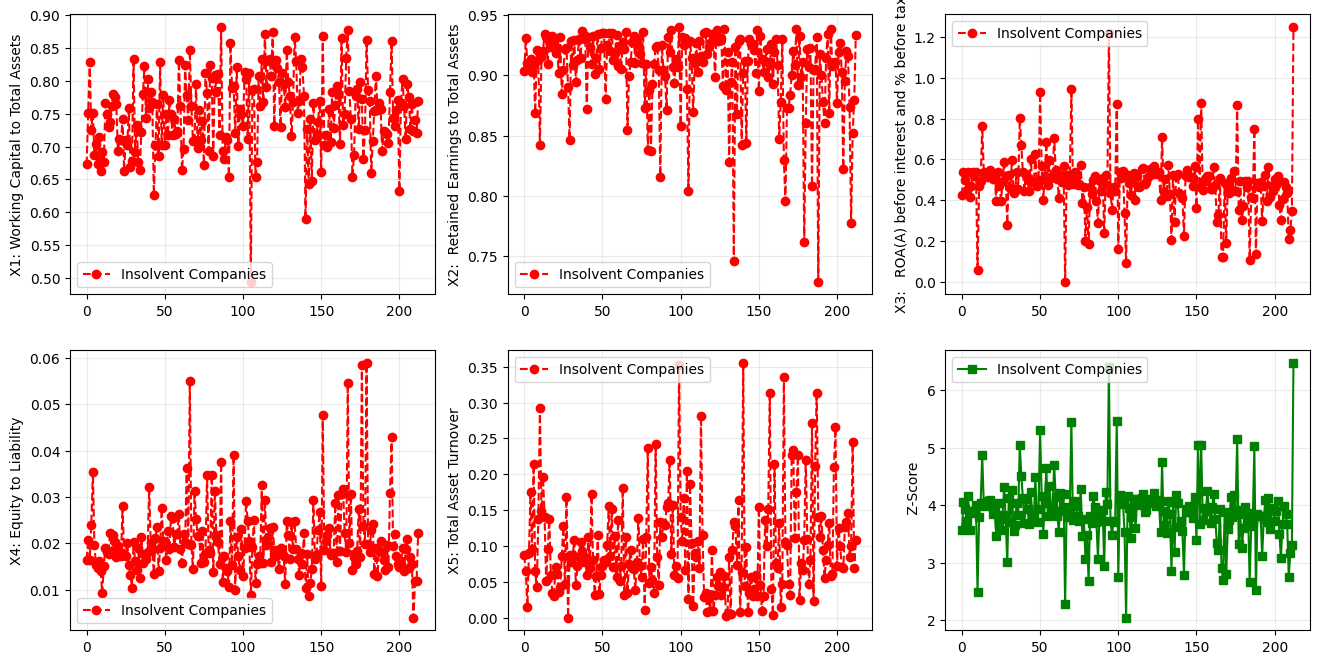

In [14]:
companies_index = np.linspace(0, len(X1_1)-1,len(X1_1))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Use the axes for plotting
axes[0,0].plot(companies_index, X1_1, 'o--r')
axes[0,0].grid('--', alpha = 0.25)
axes[0,0].set_ylabel('X1: Working Capital to Total Assets')
axes[0,0].legend(['Insolvent Companies'])


# Use the axes for plotting
axes[0,1].plot(companies_index, X1_2, 'o--r')
axes[0,1].grid('--', alpha = 0.25)
axes[0,1].set_ylabel('X2:  Retained Earnings to Total Assets')
axes[0,1].legend(['Insolvent Companies'])

# Use the axes for plotting
axes[0,2].plot(companies_index, X1_3, 'o--r')
axes[0,2].grid('--', alpha = 0.25)
axes[0,2].set_ylabel('X3:   ROA(A) before interest and % before tax')
axes[0,2].legend(['Insolvent Companies']);

# Use the axes for plotting
axes[1,0].plot(companies_index, X1_4, 'o--r')
axes[1,0].grid('--', alpha = 0.25)
axes[1,0].set_ylabel('X4: Equity to Liability')
axes[1,0].legend(['Insolvent Companies']);

# Use the axes for plotting
axes[1,1].plot(companies_index, X1_5, 'o--r')
axes[1,1].grid('--', alpha = 0.25)
axes[1,1].set_ylabel('X5: Total Asset Turnover')
axes[1,1].legend(['Insolvent Companies']);

# Use the axes for plotting
axes[1,2].plot(companies_index, Z1, 's-g')
axes[1,2].grid('--', alpha = 0.25)
axes[1,2].set_ylabel(' Z-Score')
axes[1,2].legend(['Insolvent Companies']);

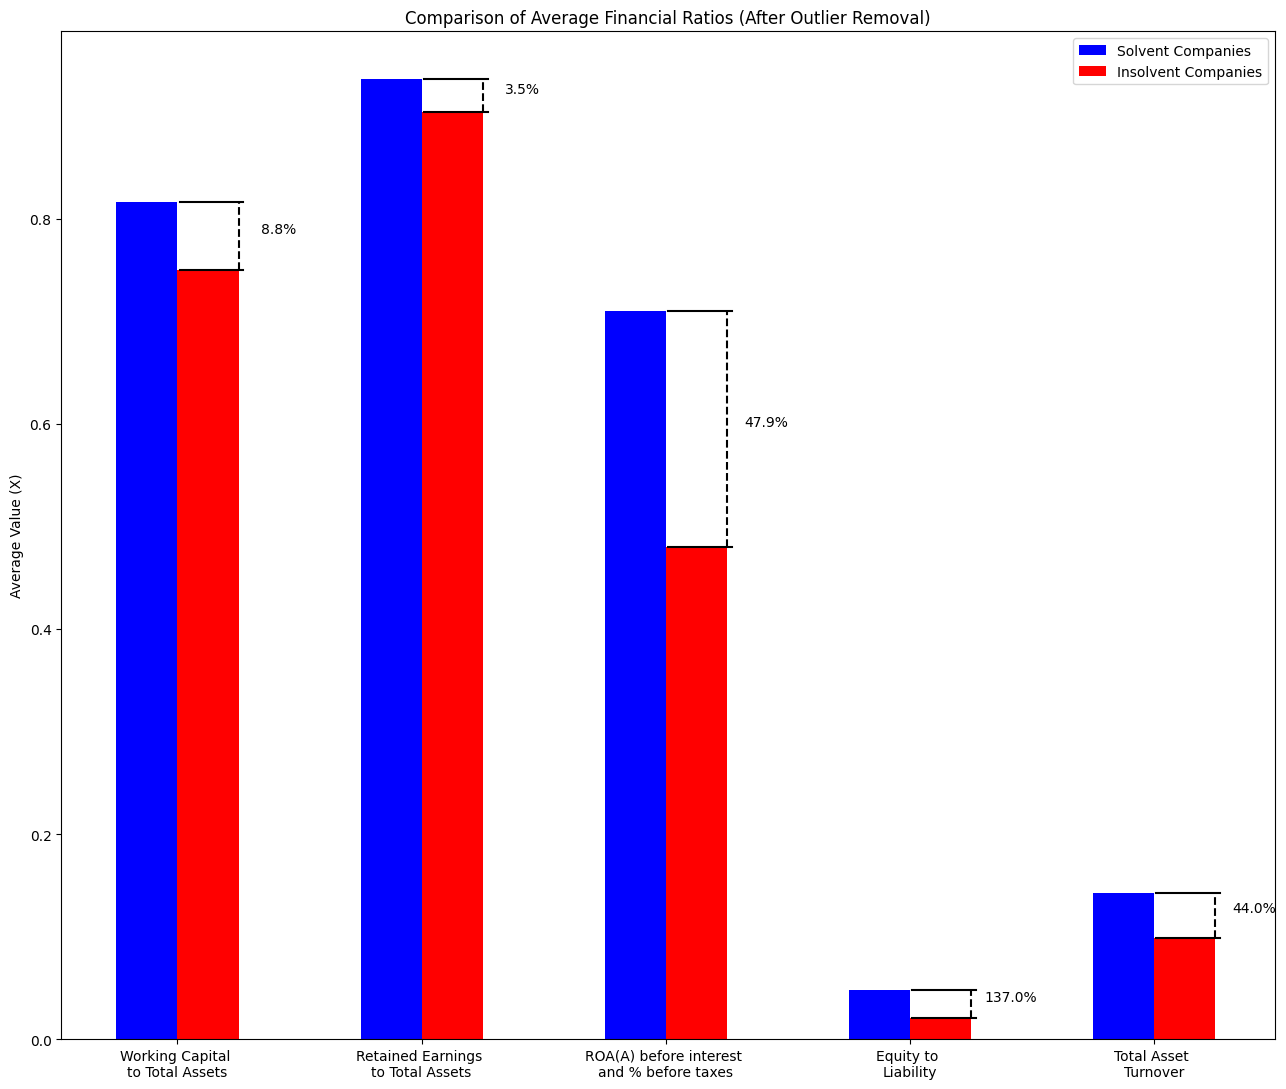

In [15]:
# Re-evaluating the averages of the five financial ratios used in the Z-Score formula
# after the removal of outliers.
# Note: These values are influenced by larger companies that are more financially stable.

X_val_dict = {
    'X':[1, 2, 3, 4, 5],
    'X avg solv': [X0_1.mean(), X0_2.mean(), X0_3.mean(), X0_4.mean(), X0_5.mean()],
    'X avg insolv': [X1_1.mean(), X1_2.mean(), X1_3.mean(), X1_4.mean(), X1_5.mean()]
}

# No sampling: Highlighting that the values are influenced by larger, more financially stable companies.

df_X_val = pd.DataFrame(X_val_dict)
df_X_val

X_var = df_X_val['X']
X_var_labels = ['Working Capital \nto Total Assets', 
                'Retained Earnings \nto Total Assets', 
                'ROA(A) before interest \nand % before taxes', 
                'Equity to \nLiability',
                'Total Asset \nTurnover']
X_avg_solv = df_X_val['X avg solv']
X_avg_insolv = df_X_val['X avg insolv']

# INITIALIZE FIGURE
plt.figure(figsize=(13,11))

# CREATE BAR CHART
bar_width = 0.25
plt.bar(X_var - bar_width/2, X_avg_solv, width=bar_width, color='blue', label='Solvent Companies')
plt.bar(X_var + bar_width/2, X_avg_insolv, width=bar_width, color='red', label='Insolvent Companies')

# ADD LABELS, LEGEND, AND TICKS
plt.title('Comparison of Average Financial Ratios (After Outlier Removal)')
plt.ylabel('Average Value (X)')
plt.legend()
plt.xticks(X_var, X_var_labels)

# Calculate and position the percentage delta
for i in range(len(X_var)):
    solvent_value = X_avg_solv[i]
    insolvent_value = X_avg_insolv[i]
    delta = ((solvent_value - insolvent_value) / insolvent_value) * 100
    
    # Text annotation for delta
    plt.text(X_var[i]+1.65*bar_width, (max(solvent_value, insolvent_value) + min(solvent_value, insolvent_value))/2, 
             f'{delta:.1f}%', ha='center', va='bottom')
    
    # Plotting the visual indicators for the difference
    plt.plot([X_var[i]+bar_width, X_var[i]+bar_width], [insolvent_value, solvent_value], color='black', linestyle='--', lw=1.5)
    plt.plot([X_var[i]+bar_width+0.02, X_var[i]+0.01], [insolvent_value, insolvent_value], color='black', lw=1.5)
    plt.plot([X_var[i]+bar_width+0.02, X_var[i]+0.01], [solvent_value, solvent_value], color='black', lw=1.5)

# DISPLAY BAR CHART
plt.tight_layout()
plt.show()

In [16]:
insolvent_companies_sampled = insolvent_companies

# Filter out the rows that meet the criteria
insolvent_companies_sampled = insolvent_companies_sampled[~(insolvent_companies_sampled[' Working Capital to Total Assets'] > 0.9)]
insolvent_companies_sampled = insolvent_companies_sampled[~(insolvent_companies_sampled[' Retained Earnings to Total Assets'] > 0.95)]
insolvent_companies_sampled = insolvent_companies_sampled[~(insolvent_companies_sampled[' ROA(A) before interest and % after tax'] > 20 * (1 - insolvent_companies_sampled[' Tax rate (A)']))]
insolvent_companies_sampled = insolvent_companies_sampled[~(insolvent_companies_sampled[' Equity to Liability'] > 0.18)]
insolvent_companies_sampled = insolvent_companies_sampled[~(insolvent_companies_sampled[' Total Asset Turnover'] > 0.4)]


In [17]:
# Solvent Companies:

# Choose between Random and Stratified Sampling:
good_companies_sampled = good_companies
stichprobenwahl = input("Random or Stratified Sampling? [R/S]")

if stichprobenwahl == "R":
    
    if len(good_companies_sampled) > len(insolvent_companies_sampled):
        while len(good_companies_sampled) > len(insolvent_companies_sampled):
            # Generate a random index between 0 and len(good_companies_sampled)-1
            zufälliger_index = random.randint(0, len(good_companies_sampled)-1)
            # Remove the row at the random index
            # Use drop to remove rows based on their position index
            good_companies_sampled = good_companies_sampled.drop(good_companies_sampled.index[zufälliger_index])
        
            print(len(good_companies_sampled))
            if len(good_companies_sampled) == len(insolvent_companies_sampled):
                break

        # Reset the index after row removal to ensure it remains continuous
        good_companies_sampled.reset_index(drop=True, inplace=True)
        
elif stichprobenwahl == "S":

    # Step 1:
    # Select solvent companies that have above-average values for X4, X3, X5, and Total Assets Growth Rate
    
    print(len(good_companies_sampled))
    
    good_companies_sampled = good_companies_sampled[good_companies_sampled[' Total Asset Growth Rate'] > TAGR_0.mean()]
    print(len(good_companies_sampled))
    
    good_companies_sampled = good_companies_sampled[good_companies_sampled[' Working Capital to Total Assets'] > X0_1.mean()]
    print(len(good_companies_sampled))
    
    good_companies_sampled = good_companies_sampled[good_companies_sampled[' Retained Earnings to Total Assets'] > X0_2.mean()]
    print(len(good_companies_sampled))
    
    # good_companies_sampled = good_companies_sampled[good_companies_sampled[' ROA(A) before interest and % after tax'] > (X0_3.mean()*(1- good_companies_sampled[' Tax rate (A)']))]
    # print(len(good_companies_sampled))
    
    good_companies_sampled = good_companies_sampled[good_companies_sampled[' Equity to Liability'] > X0_4.mean()]
    print(len(good_companies_sampled))
    
    good_companies_sampled = good_companies_sampled[good_companies_sampled[' Total Asset Turnover'] > X0_5.mean()]
    print(len(good_companies_sampled))
    
    # Step 2:
    # If the number of solvent companies still exceeds the number of insolvent companies, 
    # perform additional random sampling to balance the dataset.
    if len(good_companies_sampled) > len(insolvent_companies_sampled):
        while len(good_companies_sampled) > len(insolvent_companies_sampled):
            # Generate a random index between 0 and len(good_companies_sampled)-1
            zufälliger_index = random.randint(0, len(good_companies_sampled)-1)
            # Remove the row at the random index
            good_companies_sampled = good_companies_sampled.drop(good_companies_sampled.index[zufälliger_index])
        
            print(len(good_companies_sampled))
            if len(good_companies_sampled) == len(insolvent_companies_sampled):
                break
    
            # Reset the index after row removal to ensure it remains continuous
            good_companies_sampled.reset_index(drop=True, inplace=True)


print(len(good_companies_sampled))
good_companies_sampled

# Afterwards, a line chart will be created

Random or Stratified Sampling? [R/S] R


6598
6597
6596
6595
6594
6593
6592
6591
6590
6589
6588
6587
6586
6585
6584
6583
6582
6581
6580
6579
6578
6577
6576
6575
6574
6573
6572
6571
6570
6569
6568
6567
6566
6565
6564
6563
6562
6561
6560
6559
6558
6557
6556
6555
6554
6553
6552
6551
6550
6549
6548
6547
6546
6545
6544
6543
6542
6541
6540
6539
6538
6537
6536
6535
6534
6533
6532
6531
6530
6529
6528
6527
6526
6525
6524
6523
6522
6521
6520
6519
6518
6517
6516
6515
6514
6513
6512
6511
6510
6509
6508
6507
6506
6505
6504
6503
6502
6501
6500
6499
6498
6497
6496
6495
6494
6493
6492
6491
6490
6489
6488
6487
6486
6485
6484
6483
6482
6481
6480
6479
6478
6477
6476
6475
6474
6473
6472
6471
6470
6469
6468
6467
6466
6465
6464
6463
6462
6461
6460
6459
6458
6457
6456
6455
6454
6453
6452
6451
6450
6449
6448
6447
6446
6445
6444
6443
6442
6441
6440
6439
6438
6437
6436
6435
6434
6433
6432
6431
6430
6429
6428
6427
6426
6425
6424
6423
6422
6421
6420
6419
6418
6417
6416
6415
6414
6413
6412
6411
6410
6409
6408
6407
6406
6405
6404
6403
6402
6401
6400
6399


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0.469556,0.524913,0.522512,0.597717,0.597717,0.998956,0.797362,0.809290,0.303503,...,0.791669,0.006729,0.624564,0.597713,0.839725,0.278684,0.026482,0.563075,1,0.034416
1,0,0.480378,0.546827,0.533647,0.600751,0.600758,0.998975,0.797408,0.809332,0.303545,...,0.805085,0.001069,0.623747,0.600747,0.840697,0.278420,0.026875,0.565527,1,0.036123
2,0,0.480232,0.537069,0.534022,0.594423,0.594423,0.998919,0.797392,0.809318,0.303634,...,0.797408,0.002811,0.625141,0.594420,0.840160,0.279849,0.028787,0.568453,1,0.028963
3,0,0.496466,0.551134,0.551582,0.602409,0.602351,0.999037,0.797476,0.809394,0.303533,...,0.804678,0.017600,0.623740,0.602409,0.840623,0.277688,0.027280,0.566752,1,0.042426
4,0,0.517867,0.568578,0.568446,0.610134,0.610185,0.999103,0.797513,0.809410,0.303459,...,0.815459,0.003090,0.623670,0.610131,0.841281,0.277232,0.026915,0.565686,1,0.048183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,0,0.467606,0.534507,0.519996,0.614538,0.614581,0.999030,0.797383,0.809309,0.303386,...,0.796135,0.005738,0.623578,0.614534,0.840059,0.282328,0.037010,0.569725,1,0.022892
209,0,0.542924,0.613661,0.595642,0.652337,0.652337,0.999326,0.797748,0.809632,0.303403,...,0.837968,0.000486,0.624078,0.652338,0.842298,0.275809,0.026791,0.565158,1,0.096065
210,0,0.504656,0.562800,0.556186,0.622335,0.622335,0.999014,0.797498,0.809415,0.303619,...,0.814420,0.000152,0.623892,0.622337,0.841086,0.276228,0.026794,0.565171,1,0.072800
211,0,0.498367,0.573921,0.544944,0.618782,0.618638,0.999041,0.797547,0.809434,0.303650,...,0.820989,0.006338,0.623732,0.618782,0.841691,0.277566,0.026884,0.565567,1,0.043793


In [18]:
#We calculate key ratios and the Z-score formula for the identified solvent companies

X0_1_sampled = good_companies_sampled[' Working Capital to Total Assets']
X0_2_sampled = good_companies_sampled[' Retained Earnings to Total Assets']
X0_3_sampled = good_companies_sampled[' ROA(A) before interest and % after tax'] / (1 - good_companies_sampled[' Tax rate (A)'])
X0_4_sampled = good_companies_sampled[' Equity to Liability'] 
X0_5_sampled = good_companies_sampled[' Total Asset Turnover']

# print(len(X0_1_sampled))
# print(len(X0_2_sampled))
# print(len(X0_3_sampled))
# print(len(X0_4_sampled))
# print(len(X0_5_sampled))

Z0_sampled = 1.2*X0_1_sampled + 1.4*X0_2_sampled +3.3*X0_3_sampled + 0.6*X0_4_sampled + 1.0*X0_5_sampled

# print(len(Z0_sampled))
# print(len(good_companies_sampled))

In [19]:
# Create a new one for the extracted solvent companies

good_companies_sampled_TEMP = good_companies_sampled

good_companies_sampled_TEMP[' ROA(A) before interest and % before tax'] = good_companies_sampled[' ROA(A) before interest and % after tax']/(1 - good_companies_sampled[' Tax rate (A)'])
good_companies_sampled_TEMP[' Z-Score'] = Z0_sampled




# Keep only the columns you want
spalten_behalten = [' Working Capital to Total Assets', 
                    ' Retained Earnings to Total Assets', 
                    ' ROA(A) before interest and % before tax', 
                    ' Equity to Liability', 
                    ' Total Asset Turnover',
                    ' Z-Score',
                    ' Total Asset Growth Rate',
                    'Bankrupt?']

good_companies_sampled_XZ = good_companies_sampled_TEMP[spalten_behalten]
good_companies_sampled_XZ

,Working Capital to Total Assets,Retained Earnings to Total Assets,ROA(A) before interest and % before tax,Equity to Liability,Total Asset Turnover,Z-Score,Total Asset Growth Rate,Bankrupt?
0,0.830178,0.929953,0.524913,0.034416,0.157421,4.208431,6.630000e+09,0
1,0.770632,0.941673,0.572985,0.036123,0.214393,4.370020,6.010000e+09,0
2,0.769400,0.931854,0.583430,0.028963,0.082459,4.253030,6.510000e+09,0
3,0.772781,0.939860,0.571257,0.042426,0.061469,4.215214,6.570000e+08,0
4,0.807375,0.944436,0.690217,0.048183,0.118441,4.716127,6.920000e+09,0
...,...,...,...,...,...,...,...,...
208,0.844489,0.931433,1.829025,0.022892,0.064468,8.431380,6.270000e+09,0
209,0.925098,0.945324,0.659597,0.096065,0.091454,4.759334,9.680000e+09,0
210,0.815724,0.883145,0.578012,0.072800,0.106447,4.272839,6.700000e+09,0
211,0.760914,0.939674,0.710675,0.043793,0.112444,4.712586,5.450000e+09,0


In [20]:
# Create a new one for the extracted insolvent companies

insolvent_companies_TEMP = insolvent_companies_sampled

insolvent_companies_TEMP[' ROA(A) before interest and % before tax'] = insolvent_companies_sampled[' ROA(A) before interest and % after tax']/(1 - insolvent_companies_sampled[' Tax rate (A)'])
insolvent_companies_TEMP[' Z-Score'] = Z1


# Keep only the columns you want
spalten_behalten = [' Working Capital to Total Assets', 
                    ' Retained Earnings to Total Assets', 
                    ' ROA(A) before interest and % before tax', 
                    ' Equity to Liability', 
                    ' Total Asset Turnover',
                    ' Z-Score',
                    ' Total Asset Growth Rate',
                    'Bankrupt?']

insolvent_companies_XZ = insolvent_companies_TEMP[spalten_behalten]
insolvent_companies_XZ_reset = insolvent_companies_XZ.reset_index(drop=True)
insolvent_companies_XZ_reset

,Working Capital to Total Assets,Retained Earnings to Total Assets,ROA(A) before interest and % before tax,Equity to Liability,Total Asset Turnover,Z-Score,Total Asset Growth Rate,Bankrupt?
0,0.672775,0.903225,0.424389,0.016469,0.086957,3.569168,4.980000e+09,1
1,0.751111,0.931065,0.538214,0.020794,0.064468,4.057875,6.110000e+09,1
2,0.829502,0.909903,0.499019,0.016474,0.014993,3.940906,7.280000e+09,1
3,0.725754,0.906902,0.451265,0.023982,0.089955,3.734086,4.880000e+09,1
4,0.751822,0.913850,0.538432,0.035490,0.175412,4.155110,5.510000e+09,1
...,...,...,...,...,...,...,...,...
208,0.764816,0.873937,0.433984,0.015620,0.083958,3.666768,4.780000e+09,1
209,0.723172,0.777637,0.211023,0.003946,0.100450,2.755690,2.590000e+09,1
210,0.740426,0.852516,0.254307,0.011797,0.244378,3.172701,2.570000e+08,1
211,0.720006,0.879445,0.344636,0.011777,0.068966,3.308560,3.130000e+09,1


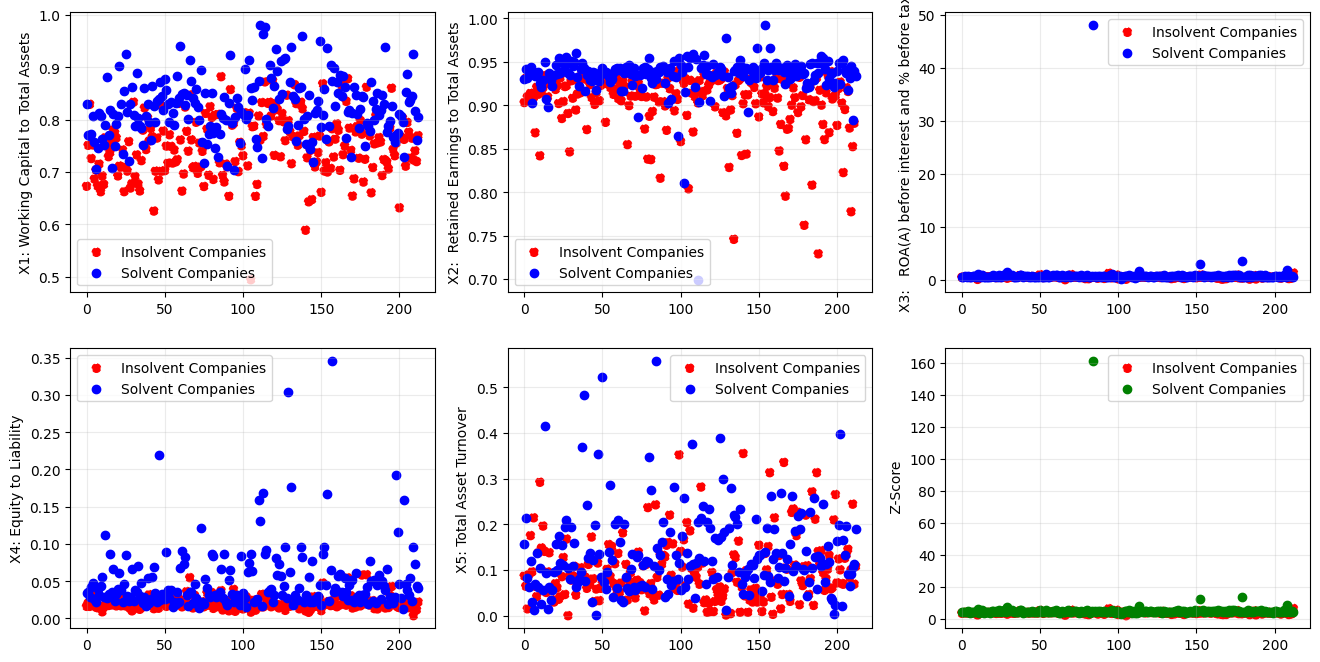

In [21]:
companies_index = np.linspace(0, len(insolvent_companies_XZ_reset)-1,len(insolvent_companies_XZ_reset))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Use the axes for plotting
axes[0,0].scatter(companies_index, insolvent_companies_XZ_reset[' Working Capital to Total Assets'], marker='o', color='r', linestyle='--')
axes[0,0].scatter(companies_index, good_companies_sampled_XZ[' Working Capital to Total Assets'], marker='o', color='b')
# axes[0,0].plot(companies_index, [good_companies_sampled_XZ[' Working Capital to Total Assets'].mean()]*len(companies_index), color='k', linestyle='--')
# axes[0,0].plot(companies_index, [insolvent_companies_XZ_reset[' Working Capital to Total Assets'].mean()]*len(companies_index), color='k', linestyle='--')
axes[0,0].grid('--', alpha = 0.25)
axes[0,0].set_ylabel('X1: Working Capital to Total Assets')
axes[0,0].legend(['Insolvent Companies', 'Solvent Companies'])


# Use the axes for plotting
axes[0,1].scatter(companies_index, insolvent_companies_XZ_reset[' Retained Earnings to Total Assets'], marker='o', color='r', linestyle='--')
axes[0,1].scatter(companies_index, good_companies_sampled_XZ[' Retained Earnings to Total Assets'], marker='o', color='b')
axes[0,1].grid('--', alpha = 0.25)
axes[0,1].set_ylabel('X2:  Retained Earnings to Total Assets')
axes[0,1].legend(['Insolvent Companies', 'Solvent Companies'])

# Use the axes for plotting
axes[0,2].scatter(companies_index, insolvent_companies_XZ_reset[' ROA(A) before interest and % before tax'], marker='o', color='r', linestyle='--')
axes[0,2].scatter(companies_index, good_companies_sampled_XZ[' ROA(A) before interest and % before tax'], marker='o', color='b')
axes[0,2].grid('--', alpha = 0.25)
axes[0,2].set_ylabel('X3:   ROA(A) before interest and % before tax')
axes[0,2].legend(['Insolvent Companies', 'Solvent Companies']);

# Use the axes for plotting
axes[1,0].scatter(companies_index, insolvent_companies_XZ_reset[' Equity to Liability'], marker='o', color='r', linestyle='--')
axes[1,0].scatter(companies_index, good_companies_sampled_XZ[' Equity to Liability'], marker='o', color='b')
axes[1,0].grid('--', alpha = 0.25)
axes[1,0].set_ylabel('X4: Equity to Liability')
axes[1,0].legend(['Insolvent Companies', 'Solvent Companies']);

# Use the axes for plotting
axes[1,1].scatter(companies_index, insolvent_companies_XZ_reset[' Total Asset Turnover'], marker='o', color='r', linestyle='--')
axes[1,1].scatter(companies_index, good_companies_sampled_XZ[' Total Asset Turnover'], marker='o', color='b')
axes[1,1].grid('--', alpha = 0.25)
axes[1,1].set_ylabel('X5: Total Asset Turnover')
axes[1,1].legend(['Insolvent Companies', 'Solvent Companies']);

# Use the axes for plotting
axes[1,2].scatter(companies_index, insolvent_companies_XZ_reset[' Z-Score'], marker='o', color='r', linestyle='--')
axes[1,2].scatter(companies_index, good_companies_sampled_XZ[' Z-Score'], marker='o', color='g')
axes[1,2].grid('--', alpha = 0.25)
axes[1,2].set_ylabel(' Z-Score')
axes[1,2].legend(['Insolvent Companies', 'Solvent Companies']);


In [22]:
# Extracting the key metrics of the insolvent companies for the box plots

Z1_bp = insolvent_companies_XZ_reset[' Z-Score']

quartile1, median, quartile3 = np.percentile(Z1, [25, 50, 75])
iqr = quartile3 - quartile1
unteres_whisker = Z1_bp[Z1_bp >= quartile1 - 1.5 * iqr].min()
oberes_whisker = Z1_bp[Z1_bp <= quartile3 + 1.5 * iqr].max()

# Defining the thresholds for outlier detection
untere_grenze = quartile1 - 1.5 * iqr
obere_grenze = quartile3 + 1.5 * iqr

# Removing outliers
bereinigte_Z1 = Z1_bp[(Z1_bp >= untere_grenze) & (Z1_bp <= obere_grenze)]

In [23]:
# Extracting the key metrics of solvent companies for the box plots

Z0_bp = good_companies_sampled_XZ[' Z-Score']

quartile1, median, quartile3 = np.percentile(Z0_bp, [25, 50, 75])

iqr = quartile3 - quartile1

unteres_whisker = Z0_bp[Z0_bp >= quartile1 - 1.5 * iqr].min()
oberes_whisker = Z0_bp[Z0_bp <= quartile3 + 1.5 * iqr].max()

# Defining the thresholds for outlier detection
untere_grenze = quartile1 - 1.5 * iqr
obere_grenze = quartile3 + 1.5 * iqr

 # Removing outliers
bereinigte_Z0 = Z0_bp[(Z0_bp >= untere_grenze) & (Z0_sampled <= obere_grenze)]

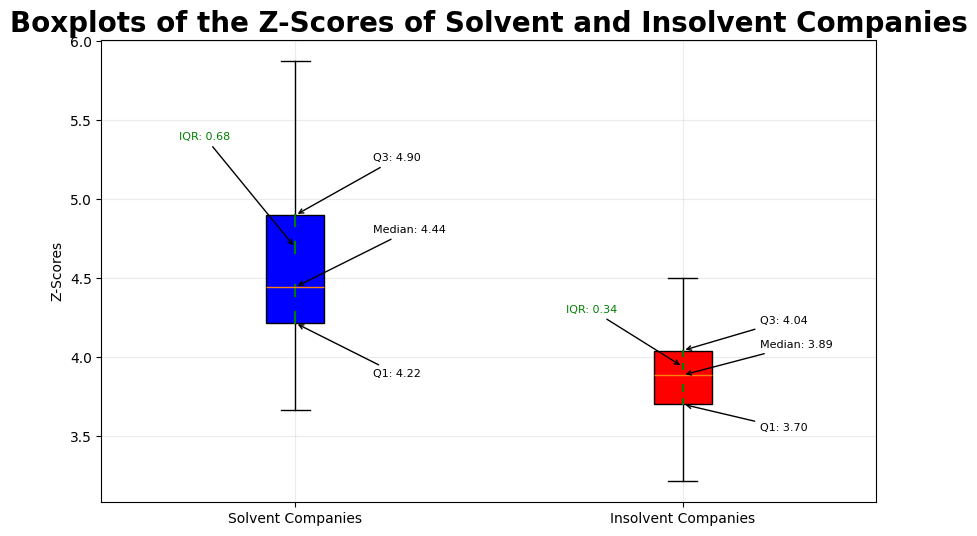

In [24]:
# Create the boxplots
box_data = [bereinigte_Z0, bereinigte_Z1]
labels = ['Solvent Companies', 'Insolvent Companies']
plt.figure(figsize=[10,6])
# Generate boxplots (hiding outliers with showfliers=False)
boxplots = plt.boxplot(box_data, patch_artist=True, tick_labels=labels, showfliers=False) 

# Set colors for the boxplots
colors = ['blue', 'red']
for patch, color in zip(boxplots['boxes'], colors):
    patch.set_facecolor(color)

# Calculate and display statistical metrics
for i, datensatz in enumerate(box_data):
    q1 = np.percentile(datensatz, 25)
    q3 = np.percentile(datensatz, 75)
    iqr = q3 - q1

    # Visualization of the brackets for the IQR (Interquartile Range)
    x_base = i + 1  # Baseline of the boxplot
    y_points = [(q1, q1 + iqr * 0.1), (q1 + iqr * 0.25, q1 + iqr * 0.35), 
                (q1 + iqr * 0.5, q3 - iqr * 0.5), (q3 - iqr * 0.35, q3 - iqr * 0.25), 
                (q3 - iqr * 0.1, q3)]
  
    for y_start, y_end in y_points:
        plt.plot([x_base, x_base], [y_start, y_end], color='green')  # Drawing a segment
    
    median = np.median(datensatz)
    lower_whisker = np.min(datensatz)
    upper_whisker = np.max(datensatz)

    # # Annotate values directly on the plot (legacy code)
    # plt.text(i + 1, q1, f'Q1: {q1:.2f}', ha='center', va='bottom', fontsize=8)
    # plt.text(i + 1, q3, f'Q3: {q3:.2f}', ha='center', va='bottom', fontsize=8)
    # plt.text(i + 1, median, f'Median: {median:.2f}', ha='center', va='bottom', fontsize=8)
    # plt.text(i + 1, q3 + iqr * 0.5, f'IQR: {iqr:.2f}', ha='right', va='bottom', fontsize=8, color='green')
    # plt.text(i + 1, lower_whisker, f'Lower Whisker: {lower_whisker:.2f}', ha='center', va='bottom', fontsize=8, color='grey')
    # plt.text(i + 1, upper_whisker, f'Upper Whisker: {upper_whisker:.2f}', ha='center', va='bottom', fontsize=8, color='grey')

    # Annotate values using arrows
    plt.annotate(f'Q1: {q1:.2f}', xy=(i + 1, q1), xytext=(i + 1.2, q1 - iqr * 0.5),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=8)
    plt.annotate(f'Q3: {q3:.2f}', xy=(i + 1, q3), xytext=(i + 1.2, q3 + iqr * 0.5),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=8)
    plt.annotate(f'Median: {median:.2f}', xy=(i + 1, median), xytext=(i + 1.2, median + iqr * 0.5),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=8)
    plt.annotate(f'IQR: {iqr:.2f}', xy=(i + 1, q3 - iqr * 0.3), xytext=(i + 0.7, q3 + iqr * 0.7),
                 arrowprops=dict(facecolor='green', arrowstyle="->"), fontsize=8, color='green')

# Visualization settings
plt.title('Boxplots of the Z-Scores of Solvent and Insolvent Companies', fontsize=20, fontweight='bold')
plt.grid('--', alpha = 0.25)
plt.ylabel('Z-Scores')

# Display the plot
plt.show()

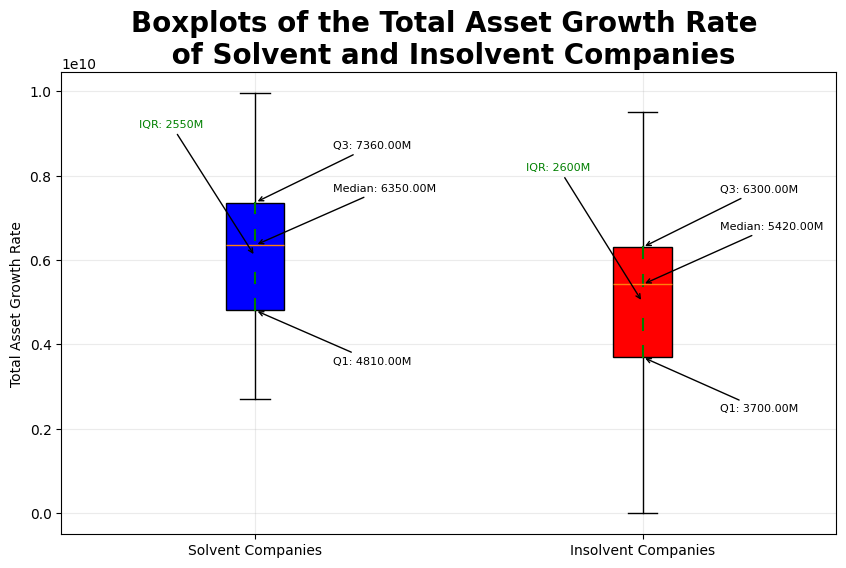

In [25]:
TAGR_0_Sampled = good_companies_sampled_XZ[' Total Asset Growth Rate']
TAGR_1_Sampled = insolvent_companies_XZ_reset[' Total Asset Growth Rate']

# Create boxplots
box_data = [TAGR_0_Sampled, TAGR_1_Sampled]
labels = ['Solvent Companies', 'Insolvent Companies']
plt.figure(figsize=[10,6])
boxplots = plt.boxplot(box_data, patch_artist=True, tick_labels=labels, showfliers=False)

# Set colors for the boxplots
colors = ['blue', 'red']
for patch, color in zip(boxplots['boxes'], colors):
    patch.set_facecolor(color)

# Calculate and display statistical metrics
for i, datensatz in enumerate(box_data):
    q1 = np.percentile(datensatz, 25)
    q3 = np.percentile(datensatz, 75)
    iqr = q3 - q1

    # Visualize brackets for the IQR (Interquartile Range)
    x_base = i + 1  # Boxplot baseline
    y_points = [(q1, q1 + iqr * 0.1), (q1 + iqr * 0.25, q1 + iqr * 0.35), 
                (q1 + iqr * 0.5, q3 - iqr * 0.5), (q3 - iqr * 0.35, q3 - iqr * 0.25), 
                (q3 - iqr * 0.1, q3)]
  
    for y_start, y_end in y_points:
        plt.plot([x_base, x_base], [y_start, y_end], color='green')  # Draw a segment
    
    median = np.median(datensatz)
    lower_whisker = np.min(datensatz)
    upper_whisker = np.max(datensatz)

    # Scale values to Millions (M)
    q1_M = q1/10**6
    q3_M = q3/10**6
    iqr_M = iqr/10**6
    median_M = median/10**6
    lower_whisker_M = lower_whisker/10**6 
    upper_whisker_M = upper_whisker/10**6

    # # Annotate values directly on the plot (legacy code)
    # plt.text(i + 1, q1, f'Q1: {q1:.2f}', ha='center', va='bottom', fontsize=8)
    # plt.text(i + 1, q3, f'Q3: {q3:.2f}', ha='center', va='bottom', fontsize=8)
    # plt.text(i + 1, median, f'Median: {median:.2f}', ha='center', va='bottom', fontsize=8)
    # plt.text(i + 1, q3 + iqr , f'IQR: {iqr_M:.0f}M', ha='right', va='top', fontsize=8, color='green')
    # plt.text(i + 1, lower_whisker, f'Lower Whisker: {lower_whisker:.2f}', ha='center', va='bottom', fontsize=8, color='grey')
    # plt.text(i + 1, upper_whisker, f'Upper Whisker: {upper_whisker:.2f}', ha='center', va='bottom', fontsize=8, color='grey')

    # Annotate values with arrows (Labels in Millions)
    plt.annotate(f'Q1: {q1_M:.2f}M', xy=(i + 1, q1), xytext=(i + 1.2, q1 - iqr * 0.5),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=8)
    plt.annotate(f'Q3: {q3_M:.2f}M', xy=(i + 1, q3), xytext=(i + 1.2, q3 + iqr * 0.5),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=8)
    plt.annotate(f'Median: {median_M:.2f}M', xy=(i + 1, median), xytext=(i + 1.2, median + iqr * 0.5),
                 arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=8)
    plt.annotate(f'IQR: {iqr_M:.0f}M', xy=(i + 1, q3 - iqr * 0.5), xytext=(i + 0.7, q3 + iqr * 0.7),
                 arrowprops=dict(facecolor='green', arrowstyle="->"), fontsize=8, color='green')

# Visualization settings
plt.title('Boxplots of the Total Asset Growth Rate \n of Solvent and Insolvent Companies', fontsize=20, fontweight='bold')
plt.grid('--', alpha = 0.25)
plt.ylabel('Total Asset Growth Rate')

# Display the plot
plt.show()

In [26]:
# Combine DataFrames 
df_companies_XZ = pd.concat([insolvent_companies_XZ_reset, good_companies_sampled_XZ], ignore_index=True)

# Show results
df_companies_XZ

# Save DataFrames into a CSV-File
df_companies_XZ.to_csv('/kaggle/working/sampled_companies.csv', index=True)

good_companies_sampled_XZ.to_csv('/kaggle/working/sampled_good_companies.csv', index=True)
insolvent_companies_XZ_reset.to_csv('/kaggle/working/sampled_insolvent_companies.csv', index=True)